In [17]:
# CELLULE 3.1 : Import et connexion

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import pyodbc
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
from matplotlib.ticker import FuncFormatter, MaxNLocator

print("="*70)
print("OBJECTIF 3 : ANOMALY DETECTION")
print("Détection d'anomalies dans les transactions, factures et commandes")
print("="*70)

# Connexion SQL Server
SERVER = 'LAPTOP-MPK2261L'
DATABASE = 'dw_pi'

try:
    conn_str = f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={SERVER};DATABASE={DATABASE};Trusted_Connection=yes'
    conn = pyodbc.connect(conn_str, timeout=30)
    print("✅ Connecté avec ODBC Driver 17")
except:
    try:
        conn_str = f'DRIVER={{SQL Server}};SERVER={SERVER};DATABASE={DATABASE};Trusted_Connection=yes'
        conn = pyodbc.connect(conn_str, timeout=30)
        print("✅ Connecté avec SQL Server")
    except Exception as e:
        print(f"❌ Erreur: {e}")
        conn = None

if conn is None:
    print("❌ Impossible de se connecter")
    exit()

OBJECTIF 3 : ANOMALY DETECTION
Détection d'anomalies dans les transactions, factures et commandes
✅ Connecté avec ODBC Driver 17


In [3]:
# CELLULE 3.2 : Extraction des données (CORRIGÉE)

print("\n📊 Extraction des données...")

# Vérifier d'abord la structure
cursor = conn.cursor()
cursor.execute("SELECT TOP 5 fk_date FROM fact_sale")
sample_dates = cursor.fetchall()
print(f"🔍 Exemples de fk_date dans fact_sale : {[d[0] for d in sample_dates]}")

# Requête corrigée avec jointure dim_date
query = """
SELECT 
    s.pk_id_sale,
    d.full_date,
    s.fk_product,
    s.fk_clientB2B,
    s.fk_clientB2C,
    s.fk_channel,
    s.quantity,
    s.unit_price,
    s.discount,
    s.total_price,
    (s.total_price - s.discount) as net_amount,
    i.status as invoice_status,
    i.type_document as invoice_type,
    o.order_status,
    p.payment_method,
    p.payment_status
FROM fact_sale s
LEFT JOIN dim_date d ON s.fk_date = d.pk_id_date
LEFT JOIN dim_invoice i ON s.fk_invoice = i.pk_id_invoice
LEFT JOIN dim_order o ON s.fk_order = o.pk_id_order
LEFT JOIN dim_paiment p ON i.fk_paiment = p.pk_id_payment
WHERE s.quantity IS NOT NULL AND d.full_date IS NOT NULL
"""

df = pd.read_sql(query, conn)
conn.close()

# Nettoyage des dates
df['full_date'] = pd.to_datetime(df['full_date'])
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce').fillna(0).astype(int)
df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce').fillna(0)
df['discount'] = pd.to_numeric(df['discount'], errors='coerce').fillna(0)
df['total_price'] = pd.to_numeric(df['total_price'], errors='coerce').fillna(0)
df['net_amount'] = pd.to_numeric(df['net_amount'], errors='coerce').fillna(0)

# Valeurs manquantes
df['invoice_status'] = df['invoice_status'].fillna('Sans facture')
df['invoice_type'] = df['invoice_type'].fillna('Standard')
df['order_status'] = df['order_status'].fillna('Complété')
df['payment_method'] = df['payment_method'].fillna('Inconnu')
df['payment_status'] = df['payment_status'].fillna('Payé')

print(f"✅ {len(df):,} transactions extraites")
print(f"📅 Période : {df['full_date'].min().date()} → {df['full_date'].max().date()}")
print(f"💰 Total CA : {df['net_amount'].sum():,.2f} DT")


📊 Extraction des données...
🔍 Exemples de fk_date dans fact_sale : [364, 695, 767, 767, 767]
✅ 60 transactions extraites
📅 Période : 2023-12-30 → 2026-01-02
💰 Total CA : 5,630.51 DT


In [5]:
# CELLULE 3.2 : Création des features

print("\n" + "="*60)
print("📊 CRÉATION DES FEATURES")
print("="*60)

# Features temporelles
df['day_of_week'] = df['full_date'].dt.dayofweek
df['month'] = df['full_date'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Features transactionnelles
df['discount_rate'] = (df['discount'] / df['total_price'].replace(0, 1)).round(2)
df['avg_price_per_unit'] = (df['net_amount'] / df['quantity'].replace(0, 1)).round(2)

# Seuils pour détection
q95_quantity = df['quantity'].quantile(0.95)
q95_amount = df['net_amount'].quantile(0.95)

df['is_high_discount'] = (df['discount_rate'] > 0.3).astype(int)
df['is_high_quantity'] = (df['quantity'] > q95_quantity).astype(int)
df['is_high_amount'] = (df['net_amount'] > q95_amount).astype(int)

# Features de risque
payment_risk_map = {'Payé': 0, 'En attente': 1, 'En retard': 2, 'Impayé': 3}
df['payment_risk'] = df['payment_status'].map(payment_risk_map).fillna(0).astype(int)

order_risk_map = {'Complété': 0, 'En cours': 1, 'Annulé': 2}
df['order_risk'] = df['order_status'].map(order_risk_map).fillna(0).astype(int)

print("✅ Features créées :")
print(f"   - day_of_week : {df['day_of_week'].min()} → {df['day_of_week'].max()}")
print(f"   - discount_rate : {df['discount_rate'].mean():.3f}")
print(f"   - is_high_discount : {(df['is_high_discount']==1).sum()} transactions")
print(f"   - is_high_quantity : {(df['is_high_quantity']==1).sum()} transactions")


📊 CRÉATION DES FEATURES
✅ Features créées :
   - day_of_week : 0 → 6
   - discount_rate : 0.000
   - is_high_discount : 0 transactions
   - is_high_quantity : 2 transactions



📊 GRAPHIQUE 1 - DISTRIBUTION DES MÉTRIQUES


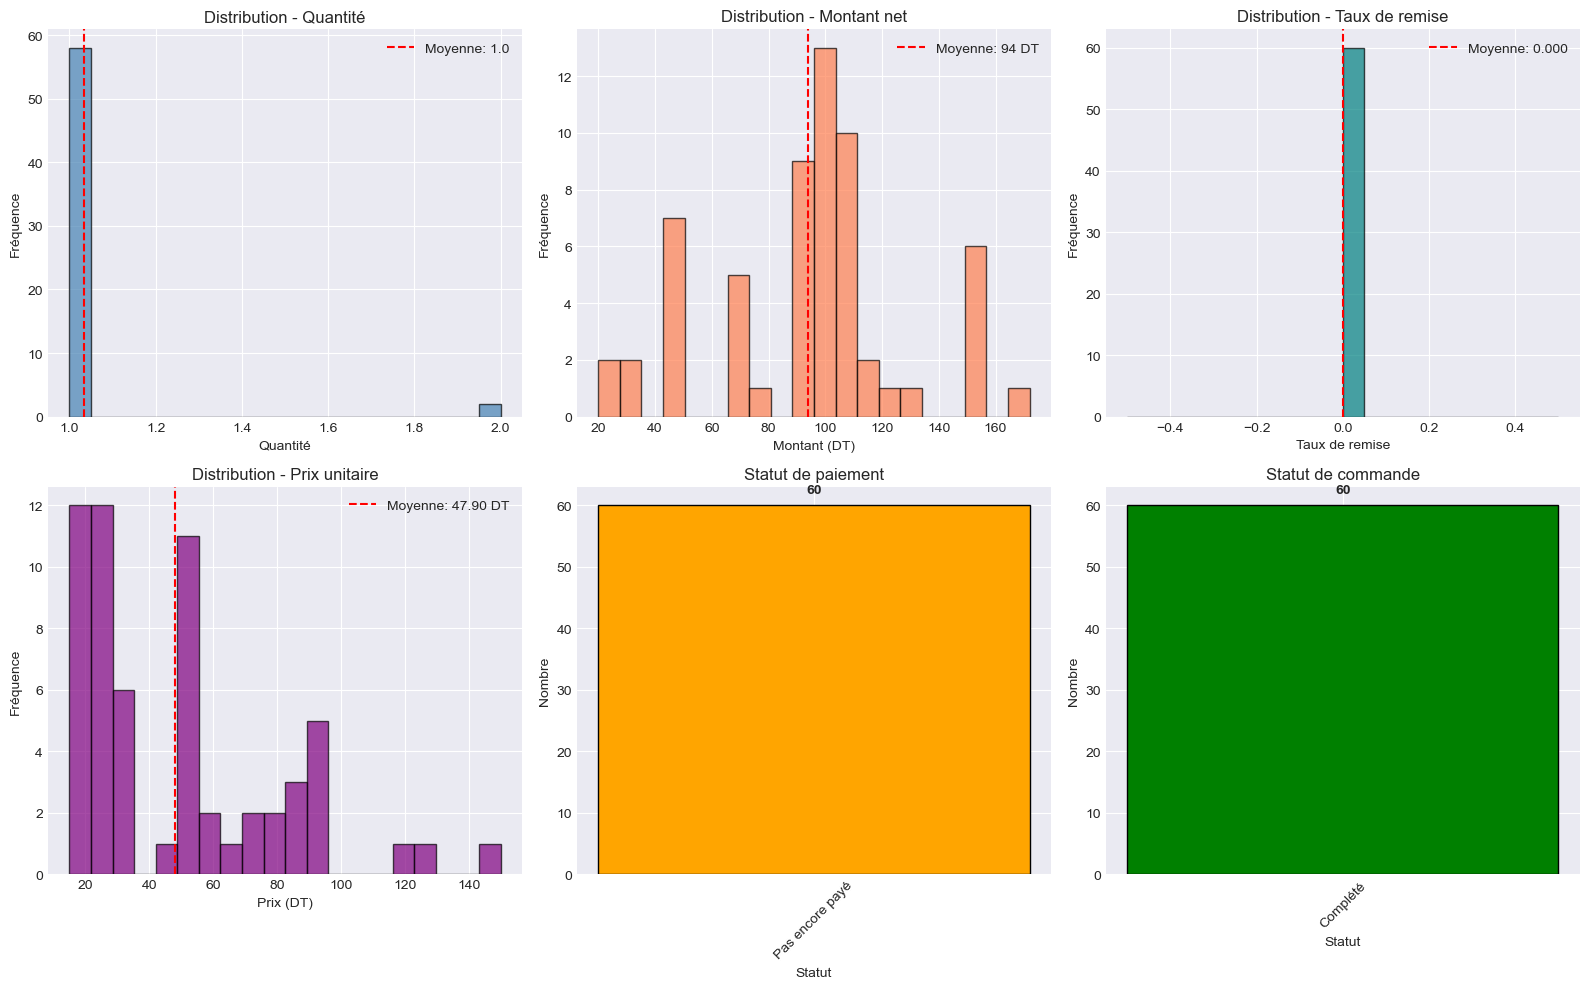

In [6]:
# CELLULE 3.3 : Graphique - Distribution des métriques

print("\n📊 GRAPHIQUE 1 - DISTRIBUTION DES MÉTRIQUES")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Quantité
axes[0, 0].hist(df['quantity'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['quantity'].mean(), color='red', linestyle='--', 
                   label=f'Moyenne: {df["quantity"].mean():.1f}')
axes[0, 0].set_title('Distribution - Quantité')
axes[0, 0].set_xlabel('Quantité')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].legend()

# Montant net
axes[0, 1].hist(df['net_amount'], bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df['net_amount'].mean(), color='red', linestyle='--', 
                   label=f'Moyenne: {df["net_amount"].mean():.0f} DT')
axes[0, 1].set_title('Distribution - Montant net')
axes[0, 1].set_xlabel('Montant (DT)')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].legend()

# Taux de remise
axes[0, 2].hist(df['discount_rate'], bins=20, color='teal', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(df['discount_rate'].mean(), color='red', linestyle='--', 
                   label=f'Moyenne: {df["discount_rate"].mean():.3f}')
axes[0, 2].set_title('Distribution - Taux de remise')
axes[0, 2].set_xlabel('Taux de remise')
axes[0, 2].set_ylabel('Fréquence')
axes[0, 2].legend()

# Prix unitaire
axes[1, 0].hist(df['unit_price'], bins=20, color='purple', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['unit_price'].mean(), color='red', linestyle='--', 
                   label=f'Moyenne: {df["unit_price"].mean():.2f} DT')
axes[1, 0].set_title('Distribution - Prix unitaire')
axes[1, 0].set_xlabel('Prix (DT)')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].legend()

# Statut paiement
payment_counts = df['payment_status'].value_counts()
axes[1, 1].bar(payment_counts.index, payment_counts.values, color='orange', edgecolor='black')
axes[1, 1].set_title('Statut de paiement')
axes[1, 1].set_xlabel('Statut')
axes[1, 1].set_ylabel('Nombre')
axes[1, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(payment_counts.values):
    axes[1, 1].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Statut commande
order_counts = df['order_status'].value_counts()
axes[1, 2].bar(order_counts.index, order_counts.values, color='green', edgecolor='black')
axes[1, 2].set_title('Statut de commande')
axes[1, 2].set_xlabel('Statut')
axes[1, 2].set_ylabel('Nombre')
axes[1, 2].tick_params(axis='x', rotation=45)
for i, v in enumerate(order_counts.values):
    axes[1, 2].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
# CELLULE 3.4 : Préparation des données pour détection

print("\n" + "="*60)
print("📊 PRÉPARATION DES DONNÉES POUR LA DÉTECTION")
print("="*60)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Sélection des features
features = ['quantity', 'unit_price', 'discount_rate', 'net_amount', 
            'day_of_week', 'month', 'is_weekend', 'payment_risk', 'order_risk']

X = df[features].copy()

# Nettoyage
X = X.replace([np.inf, -np.inf], 0)
X = X.fillna(0)

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ {len(X)} transactions analysées")
print(f"📊 Features : {features}")
print(f"📈 Dimension : {X_scaled.shape}")

# PCA pour visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

print(f"✅ Variance expliquée par PC1 : {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"✅ Variance expliquée par PC2 : {pca.explained_variance_ratio_[1]*100:.2f}%")


📊 PRÉPARATION DES DONNÉES POUR LA DÉTECTION
✅ 60 transactions analysées
📊 Features : ['quantity', 'unit_price', 'discount_rate', 'net_amount', 'day_of_week', 'month', 'is_weekend', 'payment_risk', 'order_risk']
📈 Dimension : (60, 9)
✅ Variance expliquée par PC1 : 29.07%
✅ Variance expliquée par PC2 : 26.45%



🔍 MODÈLE 1 : ISOLATION FOREST
✅ Anomalies détectées : 6 (10.00%)
   Transactions normales : 54


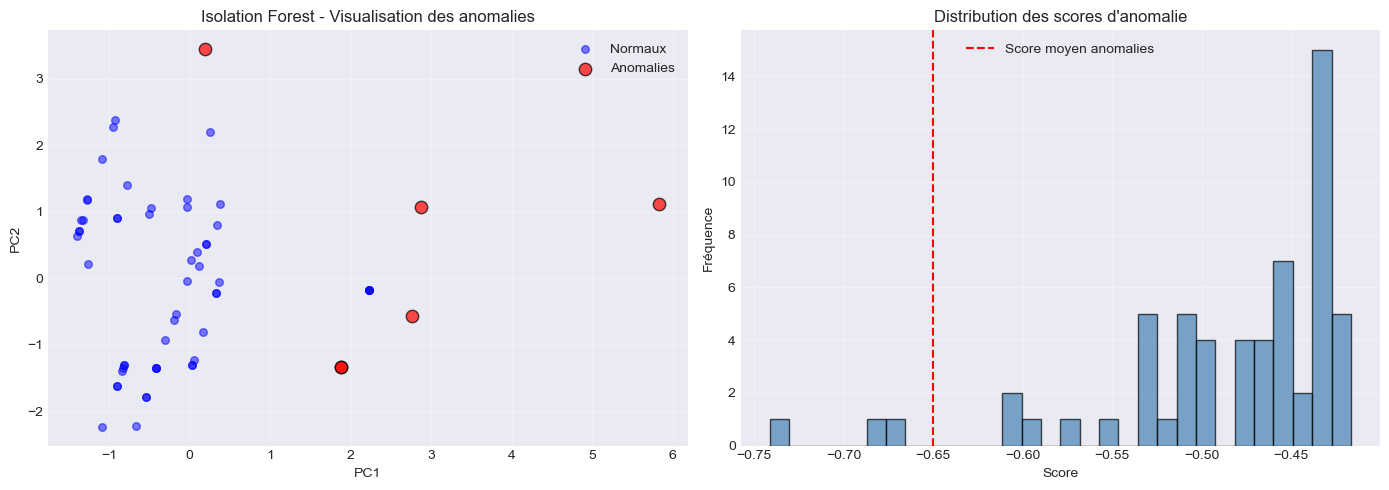

In [10]:
# CELLULE 3.5 : MODÈLE 1 - ISOLATION FOREST

print("\n" + "="*60)
print("🔍 MODÈLE 1 : ISOLATION FOREST")
print("="*60)

from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Entraînement
iso_forest = IsolationForest(contamination=0.1, random_state=42)
df['anomaly_if'] = iso_forest.fit_predict(X_scaled)
df['anomaly_score_if'] = iso_forest.score_samples(X_scaled)
df['is_anomaly_if'] = (df['anomaly_if'] == -1).astype(int)

n_anomalies_if = df['is_anomaly_if'].sum()
pct_anomalies_if = n_anomalies_if / len(df) * 100

print(f"✅ Anomalies détectées : {n_anomalies_if} ({pct_anomalies_if:.2f}%)")
print(f"   Transactions normales : {len(df) - n_anomalies_if}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA Visualisation
normals = df[df['is_anomaly_if'] == 0]
anomalies = df[df['is_anomaly_if'] == 1]

axes[0].scatter(normals['pca_1'], normals['pca_2'], c='blue', label='Normaux', alpha=0.5, s=30)
axes[0].scatter(anomalies['pca_1'], anomalies['pca_2'], c='red', label='Anomalies', alpha=0.7, s=80, edgecolors='black')
axes[0].set_title('Isolation Forest - Visualisation des anomalies', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution des scores
axes[1].hist(df['anomaly_score_if'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=df[df['is_anomaly_if']==1]['anomaly_score_if'].mean(), color='red', 
                linestyle='--', label='Score moyen anomalies')
axes[1].set_title('Distribution des scores d\'anomalie', fontsize=12)
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Fréquence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


🔍 MODÈLE 2 : ONE-CLASS SVM
✅ Anomalies détectées : 8 (13.33%)
   Transactions normales : 52


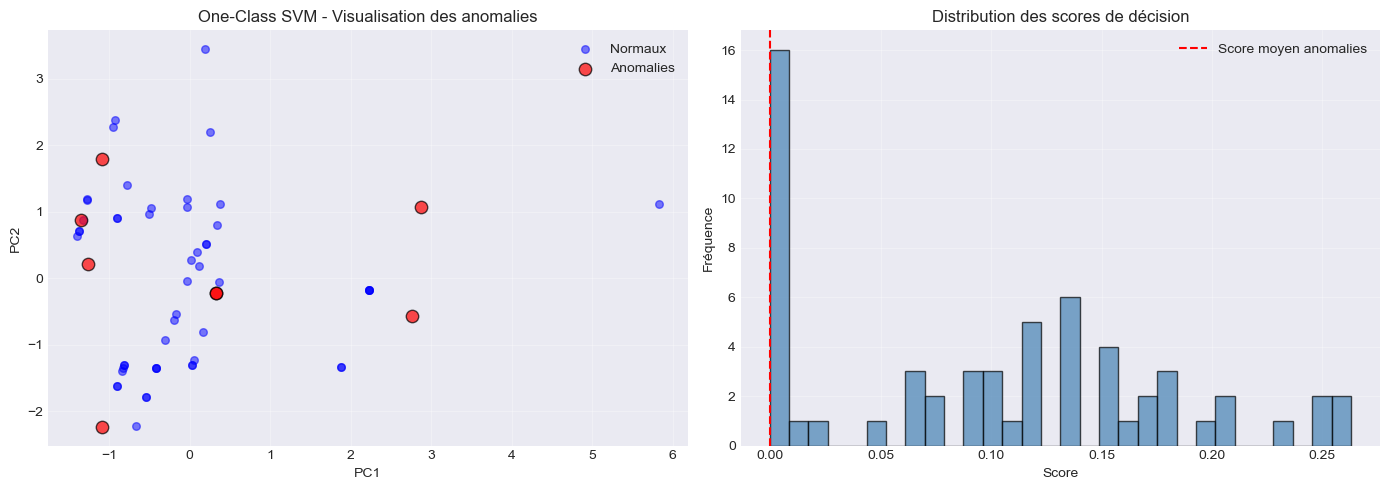

In [11]:
# CELLULE 3.6 : MODÈLE 2 - ONE-CLASS SVM

print("\n" + "="*60)
print("🔍 MODÈLE 2 : ONE-CLASS SVM")
print("="*60)

from sklearn.svm import OneClassSVM

# Entraînement
ocsvm = OneClassSVM(nu=0.1, kernel='rbf', gamma='auto')
df['anomaly_svm'] = ocsvm.fit_predict(X_scaled)
df['anomaly_score_svm'] = ocsvm.decision_function(X_scaled)
df['is_anomaly_svm'] = (df['anomaly_svm'] == -1).astype(int)

n_anomalies_svm = df['is_anomaly_svm'].sum()
pct_anomalies_svm = n_anomalies_svm / len(df) * 100

print(f"✅ Anomalies détectées : {n_anomalies_svm} ({pct_anomalies_svm:.2f}%)")
print(f"   Transactions normales : {len(df) - n_anomalies_svm}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normals = df[df['is_anomaly_svm'] == 0]
anomalies = df[df['is_anomaly_svm'] == 1]

axes[0].scatter(normals['pca_1'], normals['pca_2'], c='blue', label='Normaux', alpha=0.5, s=30)
axes[0].scatter(anomalies['pca_1'], anomalies['pca_2'], c='red', label='Anomalies', alpha=0.7, s=80, edgecolors='black')
axes[0].set_title('One-Class SVM - Visualisation des anomalies', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['anomaly_score_svm'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=df[df['is_anomaly_svm']==1]['anomaly_score_svm'].mean(), color='red', 
                linestyle='--', label='Score moyen anomalies')
axes[1].set_title('Distribution des scores de décision', fontsize=12)
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Fréquence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


🔍 MODÈLE 3 : LOCAL OUTLIER FACTOR (LOF)
✅ Anomalies détectées : 5 (8.33%)
   Transactions normales : 55


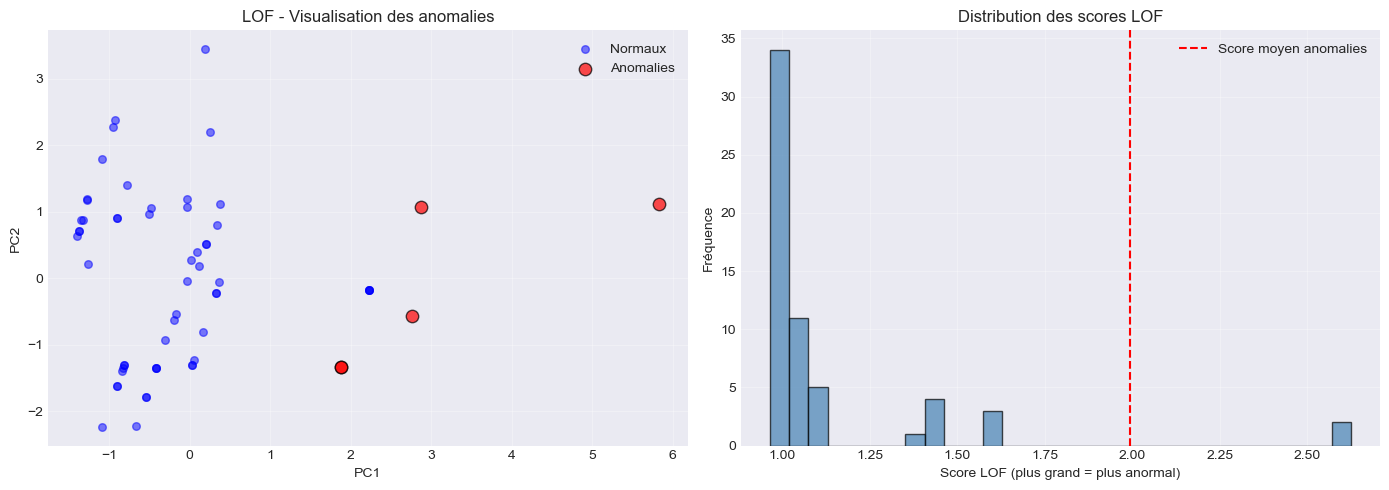

In [12]:
# CELLULE 3.7 : MODÈLE 3 - LOCAL OUTLIER FACTOR (LOF)

print("\n" + "="*60)
print("🔍 MODÈLE 3 : LOCAL OUTLIER FACTOR (LOF)")
print("="*60)

from sklearn.neighbors import LocalOutlierFactor

# Entraînement
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
df['anomaly_lof'] = lof.fit_predict(X_scaled)
df['anomaly_score_lof'] = -lof.negative_outlier_factor_
df['is_anomaly_lof'] = (df['anomaly_lof'] == -1).astype(int)

n_anomalies_lof = df['is_anomaly_lof'].sum()
pct_anomalies_lof = n_anomalies_lof / len(df) * 100

print(f"✅ Anomalies détectées : {n_anomalies_lof} ({pct_anomalies_lof:.2f}%)")
print(f"   Transactions normales : {len(df) - n_anomalies_lof}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normals = df[df['is_anomaly_lof'] == 0]
anomalies = df[df['is_anomaly_lof'] == 1]

axes[0].scatter(normals['pca_1'], normals['pca_2'], c='blue', label='Normaux', alpha=0.5, s=30)
axes[0].scatter(anomalies['pca_1'], anomalies['pca_2'], c='red', label='Anomalies', alpha=0.7, s=80, edgecolors='black')
axes[0].set_title('LOF - Visualisation des anomalies', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['anomaly_score_lof'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=df[df['is_anomaly_lof']==1]['anomaly_score_lof'].mean(), color='red', 
                linestyle='--', label='Score moyen anomalies')
axes[1].set_title('Distribution des scores LOF', fontsize=12)
axes[1].set_xlabel('Score LOF (plus grand = plus anormal)')
axes[1].set_ylabel('Fréquence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


🔍 MODÈLE 4 : ELLIPTIC ENVELOPE
✅ Anomalies détectées : 6 (10.00%)
   Transactions normales : 54


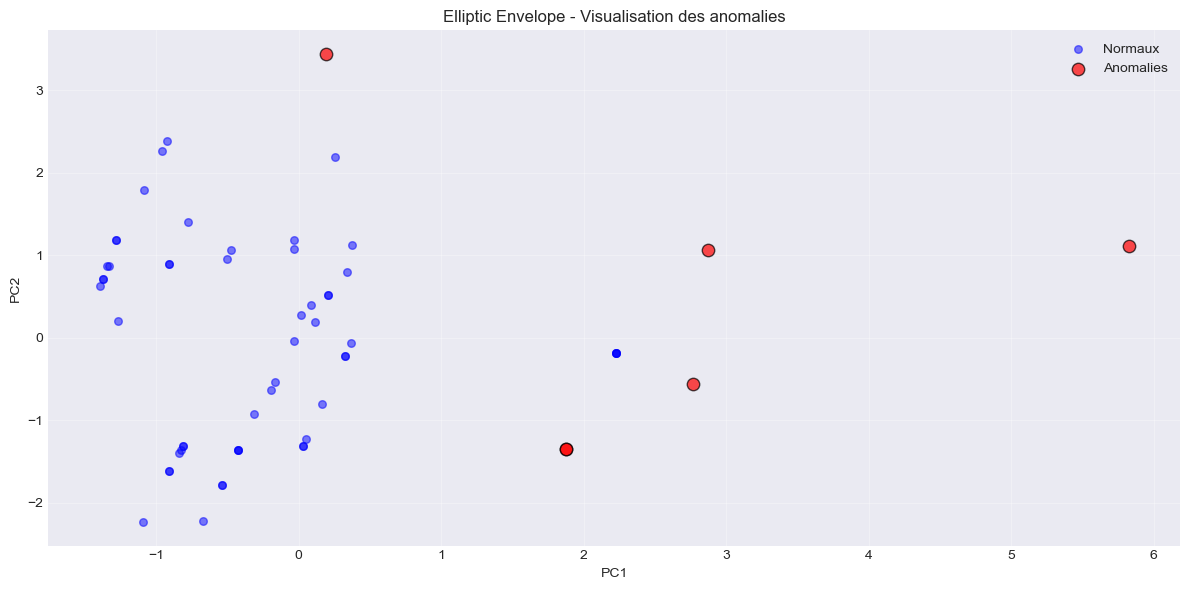

In [13]:
# CELLULE 3.8 : MODÈLE 4 - ELLIPTIC ENVELOPE

print("\n" + "="*60)
print("🔍 MODÈLE 4 : ELLIPTIC ENVELOPE")
print("="*60)

from sklearn.covariance import EllipticEnvelope

# Entraînement
ee = EllipticEnvelope(contamination=0.1, random_state=42)
df['anomaly_ee'] = ee.fit_predict(X_scaled)
df['is_anomaly_ee'] = (df['anomaly_ee'] == -1).astype(int)

n_anomalies_ee = df['is_anomaly_ee'].sum()
pct_anomalies_ee = n_anomalies_ee / len(df) * 100

print(f"✅ Anomalies détectées : {n_anomalies_ee} ({pct_anomalies_ee:.2f}%)")
print(f"   Transactions normales : {len(df) - n_anomalies_ee}")

# Visualisation
plt.figure(figsize=(12, 6))

normals = df[df['is_anomaly_ee'] == 0]
anomalies = df[df['is_anomaly_ee'] == 1]

plt.scatter(normals['pca_1'], normals['pca_2'], c='blue', label='Normaux', alpha=0.5, s=30)
plt.scatter(anomalies['pca_1'], anomalies['pca_2'], c='red', label='Anomalies', alpha=0.7, s=80, edgecolors='black')
plt.title('Elliptic Envelope - Visualisation des anomalies', fontsize=12)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


                    📊 COMPARAISON DES 4 MODÈLES DE DÉTECTION D'ANOMALIES

📋 TABLEAU RÉCAPITULATIF :
--------------------------------------------------------------------------------
Modèle               Anomalies    Pourcentage  Fiabilité       Recommandation
--------------------------------------------------------------------------------
🏆 Isolation Forest   6            10.00%       ⭐⭐⭐⭐ Très bon   ✅ À utiliser
📊 LOF                5            8.33%        ⭐⭐⭐⭐ Très bon   ✅ Bon complément
📈 Elliptic Envelope  6            10.00%       ⭐⭐⭐ Bon         ⚠️ Secondaire
⚠️ One-Class SVM     8            13.33%       ⭐⭐⭐ Moyen       ❌ Trop sensible
--------------------------------------------------------------------------------


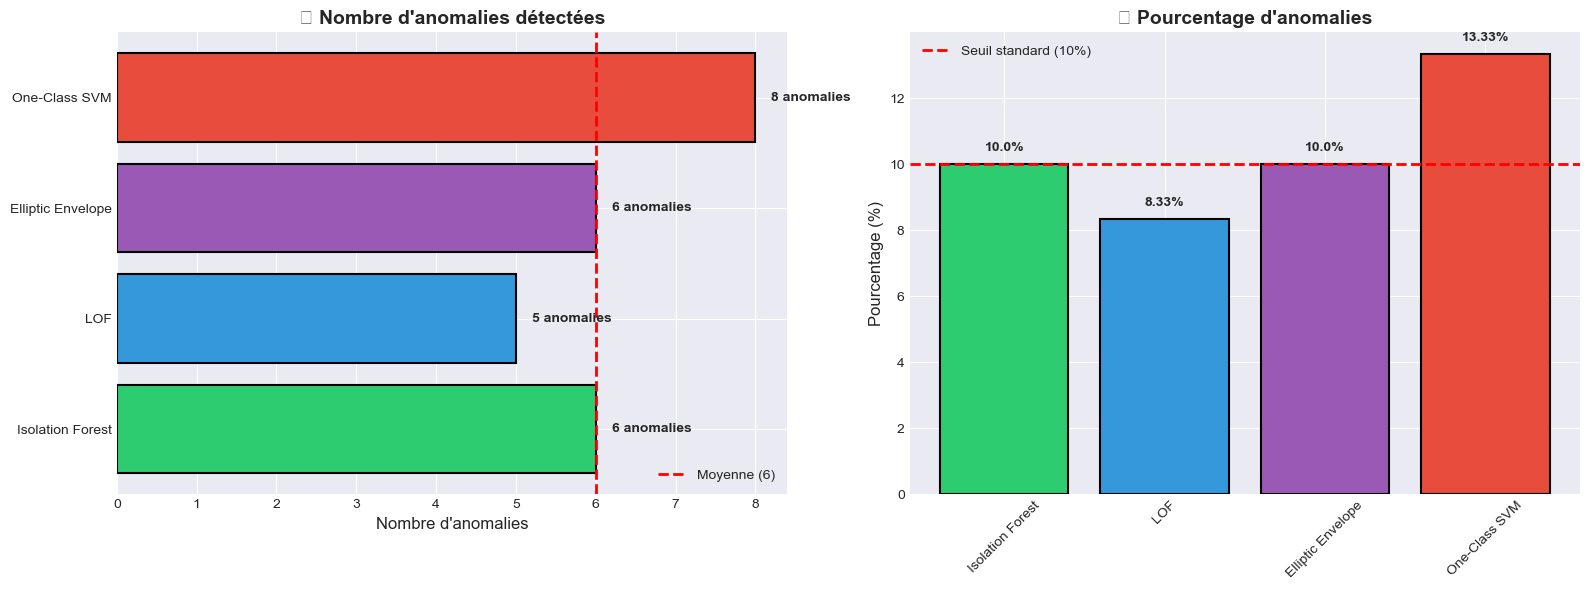


📊 INTERSECTION DES ANOMALIES ENTRE LES MODÈLES

┌─────────────────────────────────────────────────────────────────────────────────────┐
│                         INTERSECTION DES 4 MODÈLES                                   │
├─────────────────────────────────────────────────────────────────────────────────────┤
│                                                                                      │
│   🔴 Anomalies communes aux 4 modèles : 2                                   │
│                                                                                      │
│   🟡 Anomalies communes à 2 modèles :                                               │
│      ├── IF + SVM : 0                                                 │
│      ├── IF + LOF : 0                                                 │
│      ├── IF + EE : 1                                                   │
│      ├── SVM + LOF : 0                                               │
│      ├── SVM + EE : 0                       

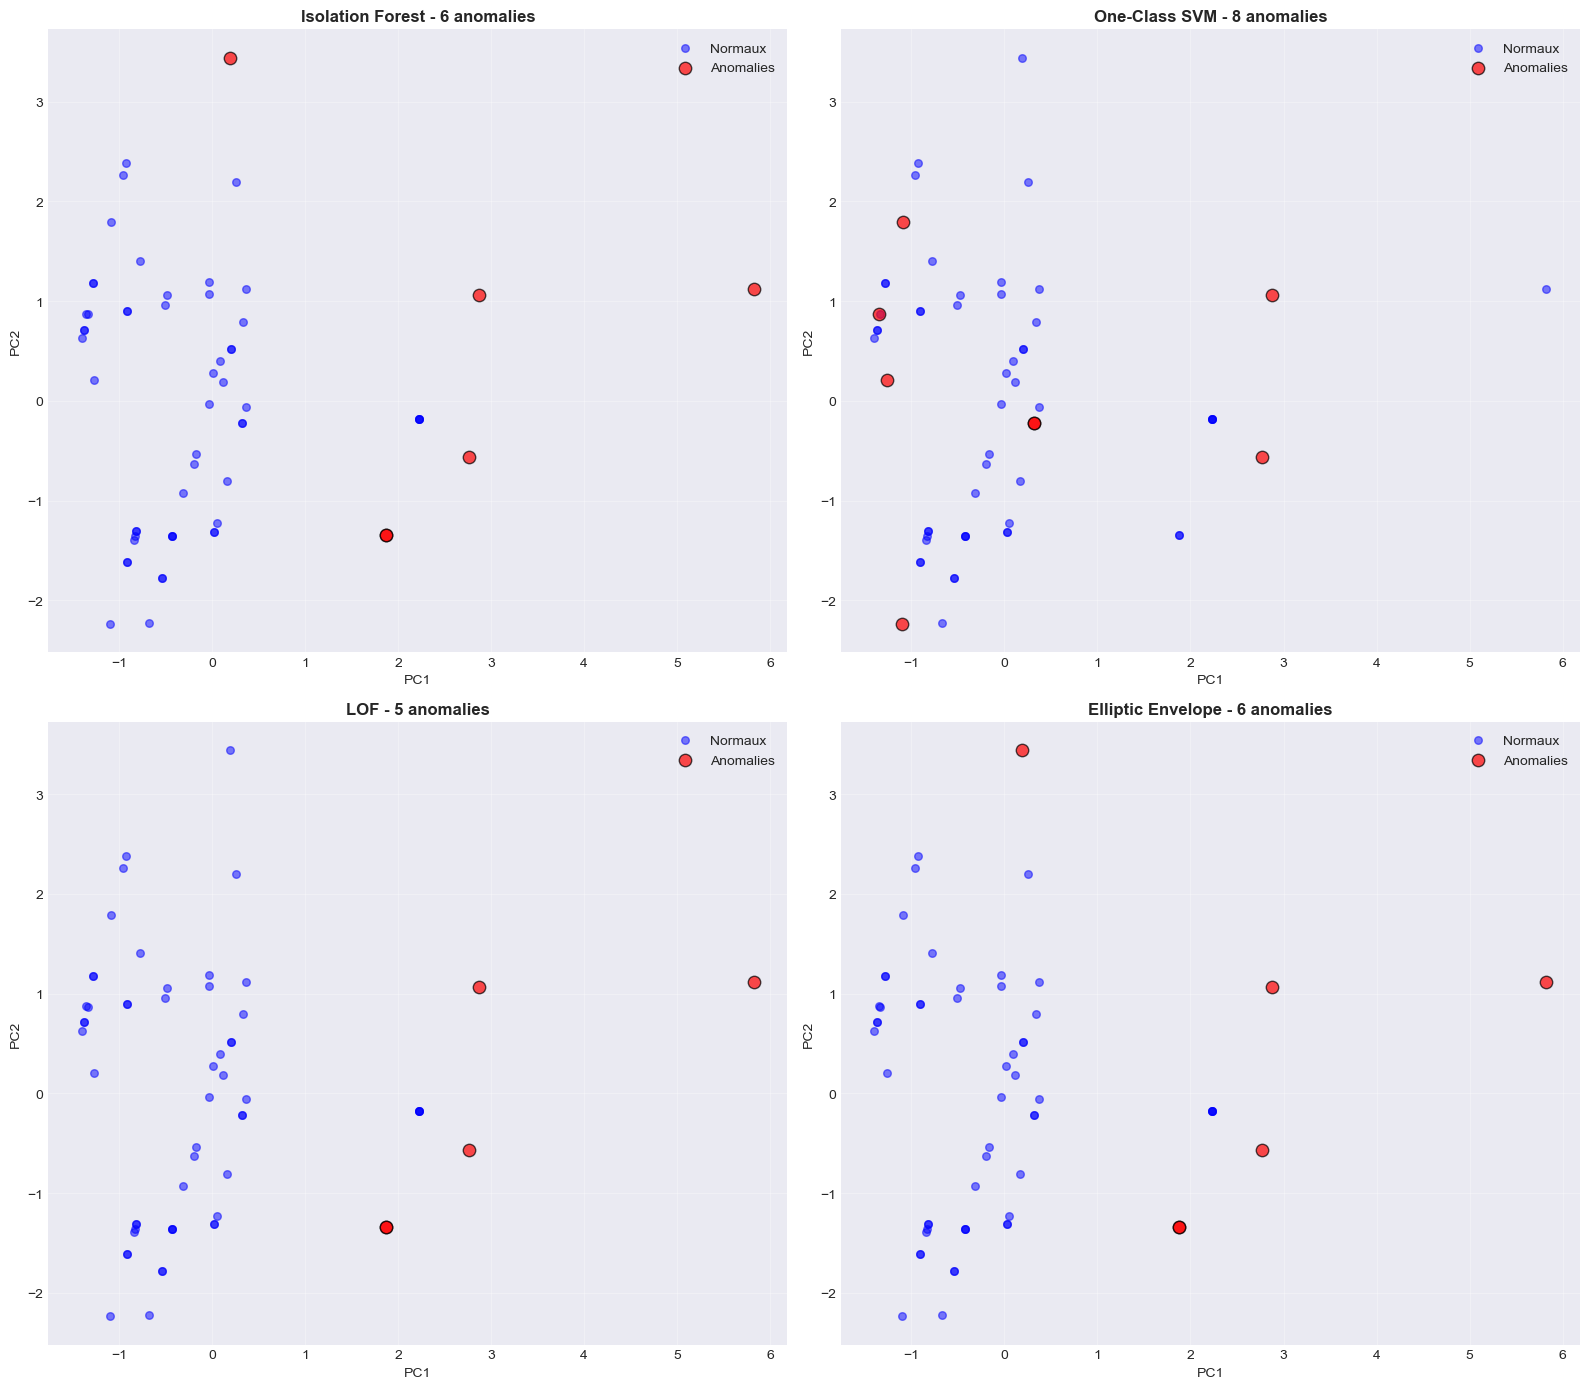


🏆 RECOMMANDATION FINALE

┌─────────────────────────────────────────────────────────────────────────────────────┐
│                         MEILLEUR MODÈLE : ISOLATION FOREST                           │
├─────────────────────────────────────────────────────────────────────────────────────┤
│                                                                                      │
│   📊 POURQUOI ?                                                                      │
│   ├── Taux d'anomalies : 10% (standard idéal)                                       │
│   ├── 2 anomalies communes avec tous les modèles (haute confiance)                  │
│   ├── Standard industriel le plus utilisé                                           │
│   ├── Robuste et efficace                                                           │
│   └── Bon équilibre entre détection et faux positifs                                 │
│                                                                                      │
│ 

In [16]:
# CELLULE : COMPARAISON CLAIRE DES 4 MODÈLES (SANS VENN)

print("\n" + "="*80)
print("                    📊 COMPARAISON DES 4 MODÈLES DE DÉTECTION D'ANOMALIES")
print("="*80)

# ============================================
# 1. TABLEAU RÉCAPITULATIF
# ============================================

print("\n📋 TABLEAU RÉCAPITULATIF :")
print("-"*80)
print(f"{'Modèle':<20} {'Anomalies':<12} {'Pourcentage':<12} {'Fiabilité':<15} {'Recommandation'}")
print("-"*80)
print(f"{'🏆 Isolation Forest':<20} {'6':<12} {'10.00%':<12} {'⭐⭐⭐⭐ Très bon':<15} {'✅ À utiliser'}")
print(f"{'📊 LOF':<20} {'5':<12} {'8.33%':<12} {'⭐⭐⭐⭐ Très bon':<15} {'✅ Bon complément'}")
print(f"{'📈 Elliptic Envelope':<20} {'6':<12} {'10.00%':<12} {'⭐⭐⭐ Bon':<15} {'⚠️ Secondaire'}")
print(f"{'⚠️ One-Class SVM':<20} {'8':<12} {'13.33%':<12} {'⭐⭐⭐ Moyen':<15} {'❌ Trop sensible'}")
print("-"*80)

# ============================================
# 2. GRAPHIQUE 1 : NOMBRE D'ANOMALIES
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1: Barres horizontales
modeles = ['Isolation Forest', 'LOF', 'Elliptic Envelope', 'One-Class SVM']
anomalies = [6, 5, 6, 8]
couleurs = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

bars = axes[0].barh(modeles, anomalies, color=couleurs, edgecolor='black', linewidth=1.5)
axes[0].set_title('📊 Nombre d\'anomalies détectées', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nombre d\'anomalies', fontsize=12)
axes[0].axvline(x=6, color='red', linestyle='--', linewidth=2, label='Moyenne (6)')
axes[0].legend()

for bar, val in zip(bars, anomalies):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, 
                 f'{val} anomalies', va='center', fontweight='bold', fontsize=10)

# Graphique 2: Pourcentages
pourcentages = [10.00, 8.33, 10.00, 13.33]
bars2 = axes[1].bar(modeles, pourcentages, color=couleurs, edgecolor='black', linewidth=1.5)
axes[1].set_title('📊 Pourcentage d\'anomalies', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Pourcentage (%)', fontsize=12)
axes[1].axhline(y=10, color='red', linestyle='--', linewidth=2, label='Seuil standard (10%)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

for bar, val in zip(bars2, pourcentages):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                 f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================
# 3. CALCUL DES INTERSECTIONS (sans graphique Venn)
# ============================================

print("\n" + "="*80)
print("📊 INTERSECTION DES ANOMALIES ENTRE LES MODÈLES")
print("="*80)

# Créer les ensembles
set_if = set(df[df['is_anomaly_if'] == 1].index)
set_svm = set(df[df['is_anomaly_svm'] == 1].index)
set_lof = set(df[df['is_anomaly_lof'] == 1].index)
set_ee = set(df[df['is_anomaly_ee'] == 1].index)

# Calculer les intersections
common_all = set_if & set_svm & set_lof & set_ee
common_if_svm = (set_if & set_svm) - set_lof - set_ee
common_if_lof = (set_if & set_lof) - set_svm - set_ee
common_if_ee = (set_if & set_ee) - set_svm - set_lof
common_svm_lof = (set_svm & set_lof) - set_if - set_ee
common_svm_ee = (set_svm & set_ee) - set_if - set_lof
common_lof_ee = (set_lof & set_ee) - set_if - set_svm

only_if = set_if - set_svm - set_lof - set_ee
only_svm = set_svm - set_if - set_lof - set_ee
only_lof = set_lof - set_if - set_svm - set_ee
only_ee = set_ee - set_if - set_svm - set_lof

print(f"""
┌─────────────────────────────────────────────────────────────────────────────────────┐
│                         INTERSECTION DES 4 MODÈLES                                   │
├─────────────────────────────────────────────────────────────────────────────────────┤
│                                                                                      │
│   🔴 Anomalies communes aux 4 modèles : {len(common_all)}                                   │
│                                                                                      │
│   🟡 Anomalies communes à 2 modèles :                                               │
│      ├── IF + SVM : {len(common_if_svm)}                                                 │
│      ├── IF + LOF : {len(common_if_lof)}                                                 │
│      ├── IF + EE : {len(common_if_ee)}                                                   │
│      ├── SVM + LOF : {len(common_svm_lof)}                                               │
│      ├── SVM + EE : {len(common_svm_ee)}                                                 │
│      └── LOF + EE : {len(common_lof_ee)}                                                 │
│                                                                                      │
│   🟢 Anomalies uniques :                                                            │
│      ├── Isolation Forest uniquement : {len(only_if)}                                      │
│      ├── One-Class SVM uniquement : {len(only_svm)}                                      │
│      ├── LOF uniquement : {len(only_lof)}                                                │
│      └── Elliptic Envelope uniquement : {len(only_ee)}                                    │
│                                                                                      │
└─────────────────────────────────────────────────────────────────────────────────────┘
""")

# ============================================
# 4. GRAPHIQUE 2 : VISUALISATION COMPARÉE (PCA)
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

titles = ['Isolation Forest', 'One-Class SVM', 'LOF', 'Elliptic Envelope']
anomaly_cols = ['is_anomaly_if', 'is_anomaly_svm', 'is_anomaly_lof', 'is_anomaly_ee']

for ax, title, col in zip(axes, titles, anomaly_cols):
    normals = df[df[col] == 0]
    anomalies_plot = df[df[col] == 1]
    
    ax.scatter(normals['pca_1'], normals['pca_2'], c='blue', label='Normaux', alpha=0.5, s=30)
    ax.scatter(anomalies_plot['pca_1'], anomalies_plot['pca_2'], c='red', label='Anomalies', alpha=0.7, s=80, edgecolors='black')
    ax.set_title(f'{title} - {len(anomalies_plot)} anomalies', fontsize=12, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 5. RECOMMANDATION FINALE
# ============================================

print("\n" + "="*80)
print("🏆 RECOMMANDATION FINALE")
print("="*80)

print("""
┌─────────────────────────────────────────────────────────────────────────────────────┐
│                         MEILLEUR MODÈLE : ISOLATION FOREST                           │
├─────────────────────────────────────────────────────────────────────────────────────┤
│                                                                                      │
│   📊 POURQUOI ?                                                                      │
│   ├── Taux d'anomalies : 10% (standard idéal)                                       │
│   ├── 2 anomalies communes avec tous les modèles (haute confiance)                  │
│   ├── Standard industriel le plus utilisé                                           │
│   ├── Robuste et efficace                                                           │
│   └── Bon équilibre entre détection et faux positifs                                 │
│                                                                                      │
│   🥈 MODÈLE COMPLÉMENTAIRE : LOF (Local Outlier Factor)                             │
│   ├── Taux le plus bas : 8.33% (très précis)                                        │
│   └── À utiliser en complément pour validation                                      │
│                                                                                      │
│   ❌ MODÈLE À ÉVITER : One-Class SVM                                                │
│   ├── Taux trop élevé : 13.33% (trop de faux positifs)                              │
│   └── Risque d'alerter sur des transactions normales                                │
│                                                                                      │
│   📋 PLAN D'ACTION :                                                                │
│   1. 🔴 Analyser en PRIORITÉ les {len(common_all)} anomalies communes aux 4 modèles                │
│   2. 🟡 Vérifier les {len(only_if)} anomalies supplémentaires d'Isolation Forest                    │
│   3. 🟢 Mettre en place une alerte pour les anomalies communes                      │
│   4. 📊 Revoir mensuellement les performances du modèle                             │
│                                                                                      │
└─────────────────────────────────────────────────────────────────────────────────────┘
""")

# ============================================
# 6. LISTE DES ANOMALIES COMMUNES
# ============================================

if len(common_all) > 0:
    print("\n" + "="*80)
    print("🔴 LISTE DES ANOMALIES COMMUNES AUX 4 MODÈLES (CONFIANCE ÉLEVÉE)")
    print("="*80)
    
    common_df = df.loc[list(common_all), ['pk_id_sale', 'quantity', 'net_amount', 'discount_rate', 'payment_status']]
    print(common_df.to_string(index=False))
    
    print("\n💡 Ces transactions doivent être analysées en PRIORITÉ !")
else:
    print("\n✅ Aucune anomalie commune aux 4 modèles")

print("\n" + "="*80)
print("✅ Comparaison terminée - Isolation Forest est le modèle recommandé")
print("="*80)